<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/06_Joining_Data_with_pandas/04_Merging_Ordered_and_Time-Series_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 4. Merging Ordered and Time-Series Data

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/S&P500.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
sp500 = pd.read_csv(url)

# Print the head of the homelessness data
print(sp500.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/WorldBank_GDP.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
gdp = pd.read_csv(url)

# Print the head of the homelessness data
print(gdp.head())

   Date  Returns
0  2008   -38.49
1  2009    23.45
2  2010    12.78
3  2011     0.00
4  2012    13.41
    Country Name Country Code     Indicator Name  Year           GDP
0          China          CHN  GDP (current US$)  2010  6.087160e+12
1        Germany          DEU  GDP (current US$)  2010  3.417090e+12
2          Japan          JPN  GDP (current US$)  2010  5.700100e+12
3  United States          USA  GDP (current US$)  2010  1.499210e+13
4          China          CHN  GDP (current US$)  2011  7.551500e+12


### Using merge_ordered()

**Correlation between GDP and S&P500**  
In this exercise, you want to analyze stock returns from the S&P 500. You believe there may be a relationship between the returns of the S&P 500 and the GDP of the US. Merge the different datasets together to compute the correlation.

Two tables have been provided for you, named sp500, and gdp. As always, pandas has been imported for you as pd.

In [9]:
# Use merge_ordered() to merge gdp and sp500 on year and date
gdp_sp500 = pd.merge_ordered(gdp, sp500, left_on="Year", right_on="Date",
                             how="left")

# Print gdp_sp500
print(gdp_sp500.head())

# Subset the gdp and returns columns
gdp_returns = gdp_sp500[["GDP", "Returns"]]

# Print gdp_returns correlation
print (gdp_returns.corr())

# You can see the different aspects of merge_ordered() and how you might use it on data that can be ordered.
# By using this function, you were able to fill in the missing data from 2019. Finally, the correlation of 0.21 between the GDP and S&P500 is low to moderate at best.
# You may want to find another predictor if you plan to play in the stock market.

    Country Name Country Code     Indicator Name  Year           GDP    Date  \
0          China          CHN  GDP (current US$)  2010  6.087160e+12  2010.0   
1        Germany          DEU  GDP (current US$)  2010  3.417090e+12  2010.0   
2          Japan          JPN  GDP (current US$)  2010  5.700100e+12  2010.0   
3  United States          USA  GDP (current US$)  2010  1.499210e+13  2010.0   
4          China          CHN  GDP (current US$)  2011  7.551500e+12  2011.0   

   Returns  
0    12.78  
1    12.78  
2    12.78  
3    12.78  
4     0.00  
              GDP   Returns
GDP      1.000000  0.016027
Returns  0.016027  1.000000


***Phillips curve using merge_ordered()***  
There is an economic theory developed by A. W. Phillips which states that inflation and unemployment have an inverse relationship. The theory claims that with economic growth comes inflation, which in turn should lead to more jobs and less unemployment.

You will take two tables of data from the U.S. Bureau of Labor Statistics, containing unemployment and inflation data over different periods, and create a Phillips curve. The tables have different frequencies. One table has a data entry every six months, while the other has a data entry every month. You will need to use the entries where you have data within both tables.

The tables unemployment and inflation have been loaded for you.

In [11]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/inflation.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
inflation = pd.read_csv(url)

# Print the head of the homelessness data
print(inflation.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/unemployment.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
unemployment = pd.read_csv(url)

# Print the head of the homelessness data
print(unemployment.head())

         date      cpi     seriesid                  data_type
0  2014-01-01  235.288  CUSR0000SA0  SEASONALLY ADJUSTED INDEX
1  2014-02-01  235.547  CUSR0000SA0  SEASONALLY ADJUSTED INDEX
2  2014-03-01  236.028  CUSR0000SA0  SEASONALLY ADJUSTED INDEX
3  2014-04-01  236.468  CUSR0000SA0  SEASONALLY ADJUSTED INDEX
4  2014-05-01  236.918  CUSR0000SA0  SEASONALLY ADJUSTED INDEX
         date  unemployment_rate
0  2013-06-01                7.5
1  2014-01-01                6.7
2  2014-06-01                6.1
3  2015-01-01                5.6
4  2015-06-01                5.3


         date      cpi     seriesid                  data_type  \
0  2014-01-01  235.288  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   
1  2014-06-01  237.231  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   
2  2015-01-01  234.718  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   
3  2015-06-01  237.684  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   
4  2016-01-01  237.833  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   
5  2016-06-01  240.167  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   
6  2017-01-01  243.780  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   
7  2017-06-01  244.182  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   
8  2018-01-01  248.884  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   
9  2018-06-01  251.134  CUSR0000SA0  SEASONALLY ADJUSTED INDEX   

   unemployment_rate  
0                6.7  
1                6.1  
2                5.6  
3                5.3  
4                5.0  
5                4.9  
6                4.7  
7                4.3  
8                4.1  
9                4.0  


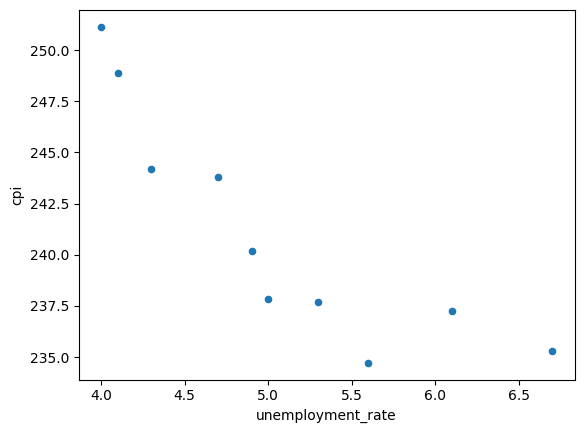

In [12]:
# Use merge_ordered() to merge inflation, unemployment with inner join
inflation_unemploy = pd.merge_ordered(inflation, unemployment, on="date", how="inner")

# Print inflation_unemploy
print(inflation_unemploy)

# Plot a scatter plot of unemployment_rate vs cpi of inflation_unemploy
inflation_unemploy.plot(kind="scatter", x="unemployment_rate", y="cpi")
plt.show()

# You created a Phillips curve. There are critics of the curve, but what is more important in this example is
# that you were able to use entries where you had entries in both tables by using an inner join. You might ask
# why not use the default outer join and use forward fill to fill to estimate the missing variables. You might
# choose differently. In this case, instead of showing an estimated unemployment rate (which is a continually changing measure)
# for five periods, that data was dropped from the plot.



**merge_ordered() caution, multiple columns**  
When using merge_ordered() to merge on multiple columns, the order is important when you combine it with the forward fill feature. The function sorts the merge on columns in the order provided. In this exercise, we will merge GDP and population data from the World Bank for Australia and Sweden, reversing the order of the merge on columns. The frequency of the series are different, the GDP values are quarterly, and the population is yearly. Use the forward fill feature to fill in the missing data. Depending on the order provided, the fill forward will use unintended data to fill in the missing values.

The tables gdp and pop have been loaded.

In [14]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/WorldBank_POP.csv"
pop = pd.read_csv(url)
print(pop.head())

  Country Name Country Code     Indicator Name  Year         Pop
0        Aruba          ABW  Population, total  2010    101669.0
1  Afghanistan          AFG  Population, total  2010  29185507.0
2       Angola          AGO  Population, total  2010  23356246.0
3      Albania          ALB  Population, total  2010   2913021.0
4      Andorra          AND  Population, total  2010     84449.0


In [20]:
# Merge gdp and pop on date and country with fill and notice rows 2 and 3
ctry_date = pd.merge_ordered(gdp, pop, on=["Year", "Country Name"],
                             fill_method='ffill')

# Print ctry_date
print(ctry_date)

            Country Name Country Code_x   Indicator Name_x  Year  \
0            Afghanistan            NaN                NaN  2010   
1                Albania            NaN                NaN  2010   
2                Algeria            NaN                NaN  2010   
3         American Samoa            NaN                NaN  2010   
4                Andorra            NaN                NaN  2010   
...                  ...            ...                ...   ...   
2643  West Bank and Gaza            USA  GDP (current US$)  2018   
2644               World            USA  GDP (current US$)  2018   
2645         Yemen, Rep.            USA  GDP (current US$)  2018   
2646              Zambia            USA  GDP (current US$)  2018   
2647            Zimbabwe            USA  GDP (current US$)  2018   

               GDP Country Code_y   Indicator Name_y           Pop  
0              NaN            AFG  Population, total  2.918551e+07  
1              NaN            ALB  Population

In [17]:
# Merge gdp and pop on country and date with fill
date_ctry = pd.merge_ordered(gdp, pop, on=["Country Name", "Year"], fill_method="ffill")

# Print date_ctry
print(date_ctry)

# When you merge on date first, the table is sorted by date then country.
# When forward fill is applied, Sweden's population value in January is used to fill in
# the missing values for both Australia and Sweden for the remainder of the year.
# This is not what you want. The fill forward is using unintended data to fill in the missing values. However, when you merge on country first,
# the table is sorted by country then date, so the forward fill is applied appropriately in this situation.

     Country Name Country Code_x   Indicator Name_x  Year           GDP  \
0     Afghanistan            NaN                NaN  2010           NaN   
1     Afghanistan            NaN                NaN  2011           NaN   
2     Afghanistan            NaN                NaN  2012           NaN   
3     Afghanistan            NaN                NaN  2012           NaN   
4     Afghanistan            NaN                NaN  2013           NaN   
...           ...            ...                ...   ...           ...   
2643     Zimbabwe            USA  GDP (current US$)  2014  2.049410e+13   
2644     Zimbabwe            USA  GDP (current US$)  2015  2.049410e+13   
2645     Zimbabwe            USA  GDP (current US$)  2016  2.049410e+13   
2646     Zimbabwe            USA  GDP (current US$)  2017  2.049410e+13   
2647     Zimbabwe            USA  GDP (current US$)  2018  2.049410e+13   

     Country Code_y   Indicator Name_y         Pop  
0               AFG  Population, total  291855

----

### Using merge_asof()

**Using merge_asof() to study stocks**  
You have a feed of stock market prices that you record. You attempt to track the price every five minutes. Still, due to some network latency, the prices you record are roughly every 5 minutes. You pull your price logs for three banks, JP Morgan (JPM), Wells Fargo (WFC), and Bank Of America (BAC). You want to know how the price change of the two other banks compare to JP Morgan. Therefore, you will need to merge these three logs into one table. Afterward, you will use the pandas .diff() method to compute the price change over time. Finally, plot the price changes so you can review your analysis.

The three log files have been loaded for you as tables named jpm, wells, and bac

In [22]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/jpm.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
jpm = pd.read_csv(url)

# Print the head of the homelessness data
print(jpm.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/wells.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
wells = pd.read_csv(url)

# Print the head of the homelessness data
print(wells.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/bac.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
bac = pd.read_csv(url)

# Print the head of the homelessness data
print(bac.head())

             date_time    close
0  2017-11-17 15:35:17  98.1200
1  2017-11-17 15:40:04  98.1800
2  2017-11-17 15:45:01  97.7307
3  2017-11-17 15:50:55  97.7400
4  2017-11-17 15:55:00  97.8150
             date_time    close
0  2017-11-17 15:35:08  54.3227
1  2017-11-17 15:40:00  54.3200
2  2017-11-17 15:45:32  54.1900
3  2017-11-17 15:50:07  54.1700
4  2017-11-17 15:55:00  54.1841
             date_time   close
0  2017-11-17 15:35:17  26.552
1  2017-11-17 15:40:06  26.552
2  2017-11-17 15:45:05  26.388
3  2017-11-17 15:50:34  26.378
4  2017-11-17 15:55:06  26.383


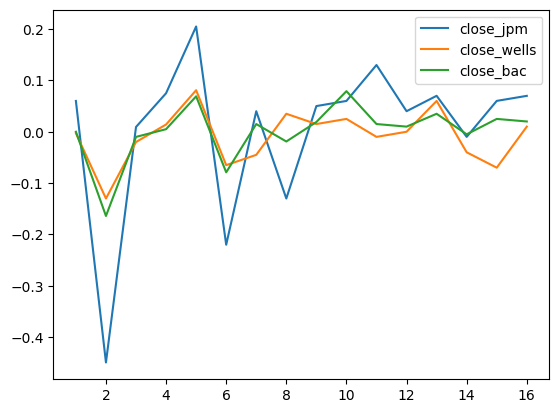

In [25]:
# Convert 'date_time' to datetime objects
jpm['date_time'] = pd.to_datetime(jpm['date_time'])
wells['date_time'] = pd.to_datetime(wells['date_time'])
bac['date_time'] = pd.to_datetime(bac['date_time'])

# Use merge_asof() to merge jpm and wells
jpm_wells = pd.merge_asof(jpm, wells, on="date_time", suffixes=('','_wells'), direction='nearest')


# Use merge_asof() to merge jpm_wells and bac
jpm_wells_bac = pd.merge_asof(jpm_wells, bac, on="date_time", suffixes=('_jpm', '_bac'), direction='nearest')


# Compute price diff
price_diffs = jpm_wells_bac.diff()

# Plot the price diff of the close of jpm, wells and bac only
price_diffs.plot(y=["close_jpm", "close_wells", "close_bac"])
plt.show()

# You can see that during this period, the price change for these bank stocks was roughly the same,
# although the price change for _JP Morgan_ was more variable.
# The critical point here is that the merge_asof() function is very useful in performing the fuzzy matching between the timestamps of all the tables.

**Using merge_asof() to create dataset**  
The merge_asof() function can be used to create datasets where you have a table of start and stop dates, and you want to use them to create a flag in another table. You have been given gdp, which is a table of quarterly GDP values of the US during the 1980s. Additionally, the table recession has been given to you. It holds the starting date of every US recession since 1980, and the date when the recession was declared to be over. Use merge_asof() to merge the tables and create a status flag if a quarter was during a recession. Finally, to check your work, plot the data in a bar chart.

The tables gdp and recession have been loaded for you

In [36]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/recession.csv"
recession = pd.read_csv(url)
print(recession.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/gdp.csv"
gdp = pd.read_csv(url)
print(gdp.head())

         date econ_status
0  1980-01-01   recession
1  1980-08-01      normal
2  1981-07-01   recession
3  1982-12-01      normal
4  1990-07-01   recession
         date       gdp
0  1979-01-01  2526.610
1  1979-04-01  2591.247
2  1979-07-01  2667.565
3  1979-10-01  2723.883
4  1980-01-01  2789.842


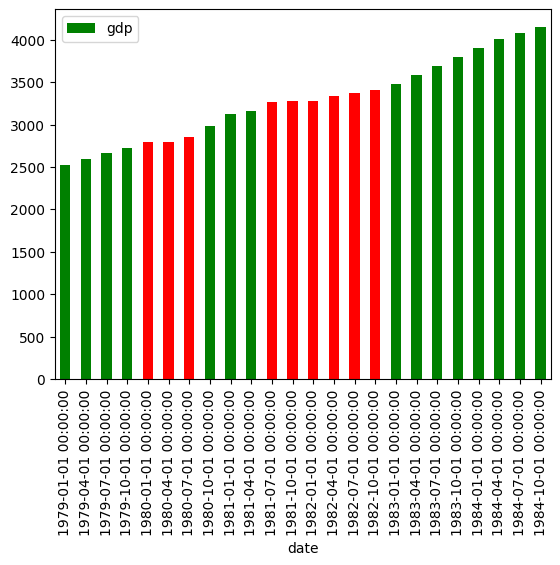

In [41]:



# Convert 'Year' in gdp to datetime objects (assuming start of the year)
gdp['date'] = pd.to_datetime(gdp['date'])

# Convert 'date' in recession to datetime objects
recession['date'] = pd.to_datetime(recession['date'])

# Use merge_asof() to merge gdp and recession on date using left_on and right_on
gdp_recession = pd.merge_asof(gdp, recession,on="date")

# Create a list based on the row value of gdp_recession['econ_status']
is_recession = ['r' if s=='recession' else 'g' for s in gdp_recession['econ_status']]

# Plot a bar chart of gdp_recession
gdp_recession.plot(kind="bar", y="gdp", x="date", color=is_recession, rot=90)
plt.show()

# You can see from the chart that there were a number of quarters early in the 1980s where a recession was an issue.
# merge_asof() allowed you to quickly add a flag to the gdp dataset by matching between two different dates,
# in one line of code! If you were to perform the same task using subsetting, it would have taken a lot more code.

**merge_asof() and merge_ordered() differences**  
The merge_asof() and merge_ordered() functions are similar in the type of merge they perform and the input arguments they use. In this exercise, think about how the functions are different.


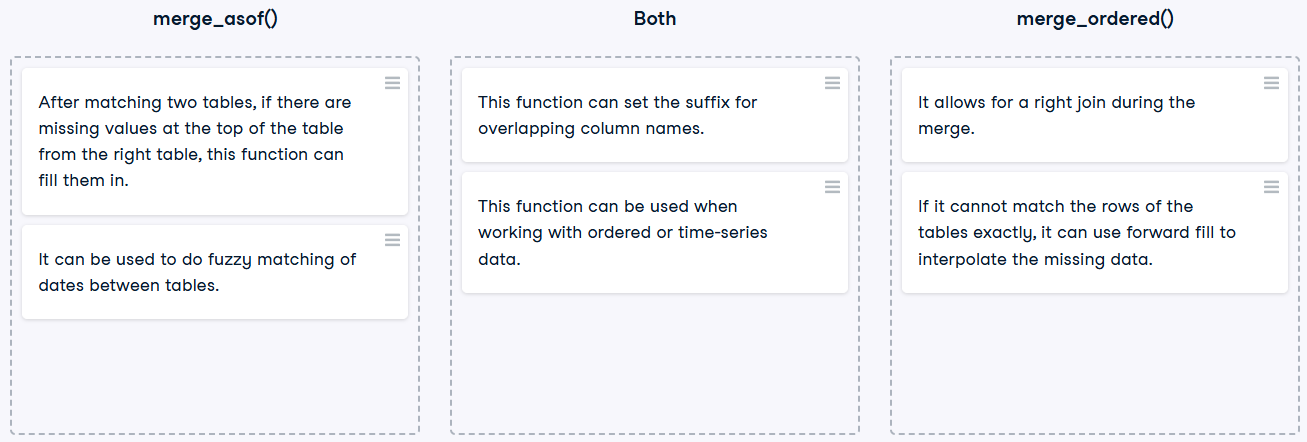

You were able to identify some of the similarities and differences between the functions. You are well on your way to mastering both!

-----

### Selecting data with .query()

**Explore financials with .query()**  
You have been given a table of financial data from some popular social network companies called social_fin. All of the values are in thousands of US dollars.

Use the .query() method to explore social_fin and select the True statement.

-> There are 6 rows where the net income has a negative value.

*To check this answer you needed to select financial equal to net income and value < 0.*

***Subsetting rows with .query()***  
In this exercise, you will revisit GDP and population data for Australia and Sweden from the World Bank and expand on it using the .query() method. You'll merge the two tables and compute the GDP per capita. Afterwards, you'll use the .query() method to sub-select the rows and create a plot. Recall that you will need to merge on multiple columns in the proper order.

The tables gdp and pop have been loaded for you.

/tmp/ipython-input-47-3594924965.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdp_pop_filtered['gdp_per_capita'] = gdp_pop_filtered['GDP'] / gdp_pop_filtered['Pop']


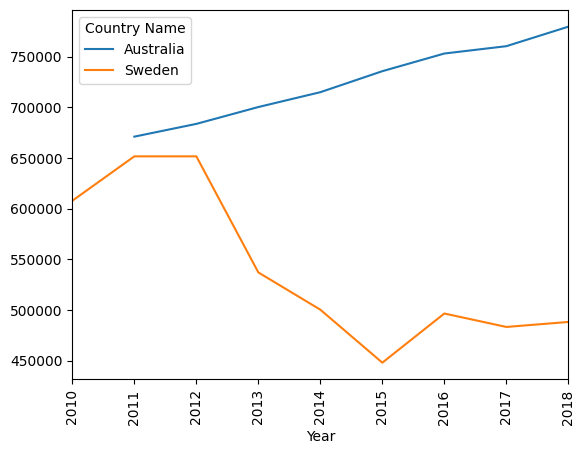

In [47]:
# Reload gdp and pop dataframes to ensure correct state
url_gdp = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/WorldBank_GDP.csv"
gdp = pd.read_csv(url_gdp)

url_pop = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/WorldBank_POP.csv"
pop = pd.read_csv(url_pop)


# Merge gdp and pop on date and country with fill
gdp_pop = pd.merge_ordered(gdp, pop, on=["Year", "Country Name"],
                             fill_method='ffill')

# Filter for Australia and Sweden
gdp_pop_filtered = gdp_pop.query('`Country Name` in ["Australia", "Sweden"]')

# Add a column named gdp_per_capita to gdp_pop that divides the gdp by pop
gdp_pop_filtered['gdp_per_capita'] = gdp_pop_filtered['GDP'] / gdp_pop_filtered['Pop']

# Pivot data so gdp_per_capita, where index is date and columns is country
gdp_pivot = gdp_pop_filtered.pivot_table('gdp_per_capita', 'Year', 'Country Name')

# Select dates equal to or greater than 1991-01-01
# Convert the index to datetime for proper comparison
gdp_pivot.index = pd.to_datetime(gdp_pivot.index, format='%Y')
recent_gdp_pop = gdp_pivot.query('index >= "1991-01-01"')


# Plot recent_gdp_pop
recent_gdp_pop.plot(rot=90)
plt.show()

# You can see from the plot that the per capita GDP of Australia passed Sweden in 1992. By using the .
# query() method, you were able to select the appropriate rows easily. The .query() method is easy to read and straightforward.

-----

### Reshaping data with .melt()

**Select the right .melt() arguments**  
You are given a table named inflation. Chose the option to get the same output as the table below.

        country    indicator  year  annual
      0   Brazil  Inflation %  2017    3.45
      1   Canada  Inflation %  2017    1.60
      2   France  Inflation %  2017    1.03
      3    India  Inflation %  2017    2.49
      4   Brazil  Inflation %  2018    3.66
      5   Canada  Inflation %  2018    2.27
      6   France  Inflation %  2018    1.85
      7    India  Inflation %  2018    4.86
      8   Brazil  Inflation %  2019    3.73
      9   Canada  Inflation %  2019    1.95
      10  France  Inflation %  2019    1.11
      11   India  Inflation %  2019    7.66


    -> inflation.melt(id_vars=['country','indicator'], var_name='year', value_name='annual')

 You identified the correct values to pass to the id_vars argument. These columns are not unpivoted. Finally, the other arguments set the name for the year and value columns.

**Using .melt() to reshape government data**  
The US Bureau of Labor Statistics (BLS) often provides data series in an easy-to-read format - it has a separate column for each month, and each year is a different row. Unfortunately, this wide format makes it difficult to plot this information over time. In this exercise, you will reshape a table of US unemployment rate data from the BLS into a form you can plot using .melt(). You will need to add a date column to the table and sort by it to plot the data correctly.

The unemployment rate data has been loaded for you in a table called ur_wide. You are encouraged to explore this table before beginning the exercise.

   year  jan  feb  mar  apr  may  jun  jul  aug  sep  oct  nov  dec
0  2010  9.8  9.8  9.9  9.9  9.6  9.4  9.4  9.5  9.5  9.4  9.8  9.3
1  2011  9.1  9.0  9.0  9.1  9.0  9.1  9.0  9.0  9.0  8.8  8.6  8.5
2  2012  8.3  8.3  8.2  8.2  8.2  8.2  8.2  8.1  7.8  7.8  7.7  7.9
3  2013  8.0  7.7  7.5  7.6  7.5  7.5  7.3  7.2  7.2  7.2  6.9  6.7
4  2014  6.6  6.7  6.7  6.2  6.3  6.1  6.2  6.1  5.9  5.7  5.8  5.6
   year  jan  feb  mar  apr  may  jun  jul  aug  sep  oct  nov  dec
0  2010  9.8  9.8  9.9  9.9  9.6  9.4  9.4  9.5  9.5  9.4  9.8  9.3
1  2011  9.1  9.0  9.0  9.1  9.0  9.1  9.0  9.0  9.0  8.8  8.6  8.5
2  2012  8.3  8.3  8.2  8.2  8.2  8.2  8.2  8.1  7.8  7.8  7.7  7.9
3  2013  8.0  7.7  7.5  7.6  7.5  7.5  7.3  7.2  7.2  7.2  6.9  6.7
4  2014  6.6  6.7  6.7  6.2  6.3  6.1  6.2  6.1  5.9  5.7  5.8  5.6


/tmp/ipython-input-49-3171483609.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ur_tall['date'] = pd.to_datetime(ur_tall['month'] + '-' + ur_tall["year"].astype(str))


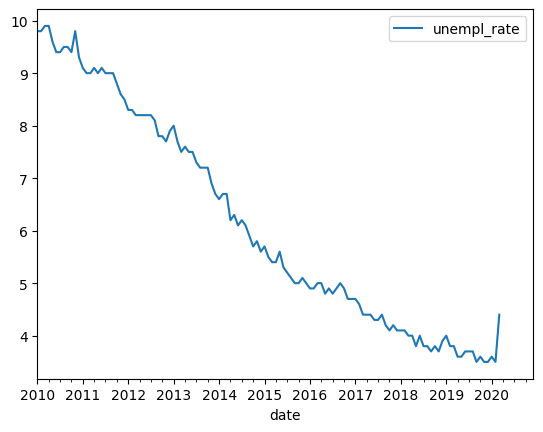

In [49]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/ur_wide.csv"
ur_wide = pd.read_csv(url)
print(ur_wide.head())

# unpivot everything besides the year column
print(ur_wide.head())
ur_tall = ur_wide.melt(id_vars=["year"], var_name="month", value_name="unempl_rate")


# Create a date column using the month and year columns of ur_tall
ur_tall['date'] = pd.to_datetime(ur_tall['month'] + '-' + ur_tall["year"].astype(str))

# Sort ur_tall by date in ascending order
ur_sorted = ur_tall.sort_values("date")

# Plot the unempl_rate by date
ur_sorted.plot(x="date", y="unempl_rate")
plt.show()

# The plot shows a steady decrease in the unemployment rate with an increase near the end.
# This increase is likely the effect of the COVID-19 pandemic and its impact on shutting down most of the US economy.
# In general, data is often provided (_especially by governments_) in a format that is easily read by people but not by machines.
# The .melt() method is a handy tool for reshaping data into a useful form

**Using .melt() for stocks vs bond performance**  
It is widespread knowledge that the price of bonds is inversely related to the price of stocks. In this last exercise, you'll review many of the topics in this chapter to confirm this. You have been given a table of percent change of the US 10-year treasury bond price. It is in a wide format where there is a separate column for each year. You will need to use the .melt() method to reshape this table.

Additionally, you will use the .query() method to filter out unneeded data. You will merge this table with a table of the percent change of the Dow Jones Industrial stock index price. Finally, you will plot data.

The tables ten_yr and dji have been loaded for you.

In [51]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/dji.csv"
dji = pd.read_csv(url)
print(dji.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/ten_yr.csv"
ten_yr = pd.read_csv(url)
print(ten_yr.head())

         date     close
0  2007-02-01  0.005094
1  2007-03-01 -0.026139
2  2007-04-01  0.048525
3  2007-05-01  0.052007
4  2007-06-01 -0.016070
  metric  2007-02-01  2007-03-01  2007-04-01  2007-05-01  2007-06-01  \
0   open    0.033491   -0.060449    0.025426   -0.004312    0.060632   
1   high   -0.007338   -0.040657    0.022046    0.030576    0.080268   
2    low   -0.016147   -0.007984    0.031075   -0.002168    0.059105   
3  close   -0.057190    0.021538   -0.003873    0.056156    0.029243   

   2007-07-01  2007-08-01  2007-09-01  2007-10-01  ...  2009-03-01  \
0    0.027154   -0.059233   -0.046271    0.014400  ...    0.045888   
1   -0.021633   -0.059796   -0.038446    0.003615  ...   -0.004257   
2   -0.027288   -0.051677   -0.043372    0.002558  ...   -0.062405   
3   -0.052056   -0.049046    0.009257   -0.022712  ...   -0.117067   

   2009-04-01  2009-05-01  2009-06-01  2009-07-01  2009-08-01  2009-09-01  \
0   -0.102599    0.191049    0.106726    0.023966   -0.006687   -0.

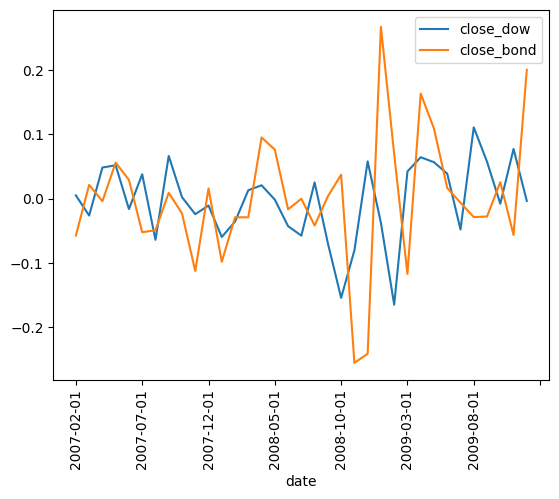

In [52]:
# Use melt on ten_yr, unpivot everything besides the metric column
bond_perc = ten_yr.melt(id_vars="metric", var_name="date", value_name="close")

# Use query on bond_perc to select only the rows where metric=close
bond_perc_close = bond_perc.query('metric == "close"')

# Merge (ordered) dji and bond_perc_close on date with an inner join
dow_bond = pd.merge_ordered(dji, bond_perc_close, on="date", how="inner", suffixes=('_dow','_bond'))


# Plot only the close_dow and close_bond columns
dow_bond.plot(y=["close_dow", "close_bond"], x='date', rot=90)
plt.show()

# You used many of the techniques we have reviewed in this chapter to produce the plot.
# The plot confirms that the bond and stock prices are inversely correlated.
# Often as the price of stocks increases, the price for bonds decreases.